# Publication figures — Flappy pretrain (binary)

Loads trial results, groups by **trial name** (all parameters except seed), and plots mean ± std across seeds.

**Ablation figures** — one figure per **task** (`TASKS_TO_PLOT`: Passive, Active, Pooled):
- **Subplots** = neural conditions (Baseline-PER, Prioritization, Reward Augmentation, …)
- **Lines** = ablation values (model noise at β=1, or β at noise=0)

**Summary** — one figure, three subplots (Passive / Active / Pooled); all conditions as lines at best noise and β


In [77]:
import ast
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "lines.linewidth": 2.0,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TASKS_TO_PLOT = ["Passive", "Active", "Pooled"]



In [87]:
DATA_FILE = "trial_results_pretrain_binary_flappy.csv"
SEED_COLUMN = "parameters_experiment_random_state"
# "results_success_rate" or "results_total_reward" (reward is mean return per eval checkpoint)
METRIC = "results_success_rate"
METRIC_LABELS = {
    "results_success_rate": "Evaluation success rate",
    "results_total_reward": "Mean evaluation return",
    "results_steps": "Steps at evaluation",
}
METRIC_LABEL = METRIC_LABELS[METRIC]
WINDOW_SIZE = 5
FINAL_WINDOW = 50

CONDITION_COLUMN = "parameters_experiment_condition"
TASK_COLUMN = "parameters_experiment_task"
NOISE_COLUMN = "parameters_mlp_model_noise"
BETA_COLUMN = "parameters_neural_beta"

ABLATION_NOISE_BASELINE_BETA = 1.0
ABLATION_BETA_BASELINE_NOISE = 0.0
ABLATION_CONDITION = "Baseline-PER"

CONDITION_ORDER = [
    "Baseline-PER", "Prioritization", "Q-Augmentation",
    "Reward Augmentation", "All-PER",
]
TASK_ORDER = ["Passive", "Active", "Pooled"]
NOISE_ORDER = [0.0, 0.1, 0.5, 1.0]
BETA_ORDER = [0.5, 1.0, 5.0, 10.0]

SAVE_FIGURES = True
FIGURES_DIR = Path("figures_publication")


In [88]:
def resolve_data_path(filename: str) -> Path:
    here = Path.cwd()
    search_dirs = [here, here / "src" / "results"]
    for parent in [here, *here.parents]:
        candidate = parent / "src" / "results"
        if candidate.is_dir() and candidate not in search_dirs:
            search_dirs.append(candidate)
    for d in search_dirs:
        path = d / filename
        if path.is_file():
            return path
    raise FileNotFoundError(f"Could not find {filename}")


def read_results_csv(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except pd.errors.ParserError:
        return pd.read_csv(path, engine="python", on_bad_lines="skip")


PATH = resolve_data_path(DATA_FILE)
raw = read_results_csv(PATH)
print(f"Loaded {len(raw)} rows from {PATH}")


Loaded 1665 rows from /Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/trial_results_pretrain_binary_flappy.csv


In [89]:
def make_trial_name(row: pd.Series) -> str:
    return (
        f"{row['parameters_experiment_domain']}__{row['parameters_experiment_task']}__"
        f"{row['parameters_experiment_condition']}__{row['parameters_experiment_integration_type']}__"
        f"{row['parameters_experiment_model_granularity']}__"
        f"noise{row[NOISE_COLUMN]}__beta{row[BETA_COLUMN]}"
    )


def parse_series(value) -> np.ndarray:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.array([], dtype=float)
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
        except (SyntaxError, ValueError):
            return np.array([], dtype=float)
        return np.asarray(parsed, dtype=float)
    return np.asarray(value, dtype=float)


def parse_metric_series(row: pd.Series, metric_col: str) -> np.ndarray:
    arr = parse_series(row[metric_col])
    if metric_col != "results_total_reward" or len(arr) == 0:
        return arr

    # Training does all_total_rewards.extend(eval_reward) → 10 returns per eval,
    # while success_rate has one entry per eval. Align by chunking.
    if "results_success_rate" in row.index:
        n_checkpoints = len(parse_series(row["results_success_rate"]))
    else:
        n_checkpoints = 0

    if n_checkpoints > 0 and len(arr) % n_checkpoints == 0:
        chunk = len(arr) // n_checkpoints
        return np.nanmean(arr.reshape(n_checkpoints, chunk), axis=1)

    # Fallback (pretrain offline eval uses 10 episodes)
    chunk = 10
    n_checkpoints = len(arr) // chunk
    if n_checkpoints == 0:
        return arr
    return np.nanmean(arr[: n_checkpoints * chunk].reshape(n_checkpoints, chunk), axis=1)


def moving_average(arr: np.ndarray, window: int) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    if window <= 1 or len(arr) < window:
        return arr
    csum = np.cumsum(np.nan_to_num(arr), dtype=float)
    csum[window:] = csum[window:] - csum[:-window]
    return csum[window - 1:] / window


def aggregate_seed_rows(rows: pd.DataFrame, metric_col: str, window: int):
    series = [moving_average(parse_series(v), window) for v in rows[metric_col]]
    series = [s for s in series if len(s)]
    if not series:
        return np.array([]), np.array([]), 0
    max_len = max(len(s) for s in series)
    padded = [np.pad(s, (0, max_len - len(s)), constant_values=np.nan) for s in series]
    stacked = np.vstack(padded)
    return np.nanmean(stacked, axis=0), np.nanstd(stacked, axis=0), stacked.shape[0]


def sort_named(values, order: list):
    rank = {v: i for i, v in enumerate(order)}
    return sorted(values, key=lambda v: (rank.get(v, 999), str(v)))


def final_score(mean_curve: np.ndarray, tail: int = FINAL_WINDOW) -> float:
    if len(mean_curve) == 0:
        return np.nan
    k = min(tail, len(mean_curve))
    return float(np.nanmean(mean_curve[-k:]))


raw["trial_name"] = raw.apply(make_trial_name, axis=1)
print(f"{raw['trial_name'].nunique()} unique trial names; "
      f"seeds/trial: {raw.groupby('trial_name')[SEED_COLUMN].nunique().median():.0f} median")


96 unique trial names; seeds/trial: 15 median


In [90]:
def build_aggregated_table(df: pd.DataFrame, metric_col: str = METRIC) -> pd.DataFrame:
    records = []
    for trial_name, grp in df.groupby("trial_name", sort=False):
        mean, std, n_seeds = aggregate_seed_rows(grp, metric_col, WINDOW_SIZE)
        rep = grp.iloc[0]
        records.append({
            "trial_name": trial_name,
            "mean": mean,
            "std": std,
            "n_seeds": n_seeds,
            "task": rep[TASK_COLUMN],
            "condition": rep[CONDITION_COLUMN],
            "noise": float(rep[NOISE_COLUMN]),
            "beta": float(rep[BETA_COLUMN]),
            "final_score": final_score(mean),
        })
    return pd.DataFrame(records)


agg = build_aggregated_table(raw)
agg.head()


,trial_name,mean,std,n_seeds,task,condition,noise,beta,final_score
0,Flappy__Passive__Baseline-PER__pretrain__binar...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",30,Passive,Baseline-PER,0.0,1.0,0.397200
1,Flappy__Active__Baseline-PER__pretrain__binary...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",30,Active,Baseline-PER,0.0,1.0,0.869267
2,Flappy__Pooled__Baseline-PER__pretrain__binary...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",30,Pooled,Baseline-PER,0.0,1.0,0.753200
3,Flappy__Passive__Prioritization__pretrain__bin...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",30,Passive,Prioritization,0.0,1.0,0.325899
4,Flappy__Passive__Prioritization__pretrain__bin...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",15,Passive,Prioritization,0.1,1.0,0.762200


In [91]:
def select_best_ablation(table: pd.DataFrame, *, ablation_col: str, beta=None, noise=None, condition=ABLATION_CONDITION) -> float:
    sub = table[table["condition"] == condition]
    if beta is not None:
        sub = sub[np.isclose(sub["beta"], beta)]
    if noise is not None:
        sub = sub[np.isclose(sub["noise"], noise)]
    if sub.empty:
        raise ValueError(f"No trials for selection: {ablation_col}, beta={beta}, noise={noise}")

    ranked = sub.groupby(ablation_col)["final_score"].mean().sort_values(ascending=False)
    best = float(ranked.index[0])
    print(f"Best {ablation_col} = {best}  (mean final {METRIC_LABEL} = {ranked.iloc[0]:.3f})")
    print(ranked.to_string())
    return best


best_noise = select_best_ablation(agg, ablation_col="noise", beta=ABLATION_NOISE_BASELINE_BETA)
best_beta = select_best_ablation(agg, ablation_col="beta", noise=ABLATION_BETA_BASELINE_NOISE)
print(f"Condition figure will use noise={best_noise}, beta={best_beta}")


Best noise = 0.0  (mean final Evaluation success rate = 0.673)
noise
0.0    0.673222
Best beta = 1.0  (mean final Evaluation success rate = 0.673)
beta
1.0     0.673222
10.0    0.608933
0.5     0.538447
5.0     0.505667
Condition figure will use noise=0.0, beta=1.0


In [92]:
def plot_mean_std(ax, mean, std, label, color):
    if len(mean) == 0:
        return False
    x = np.arange(len(mean))
    ax.plot(x, mean, label=label, color=color)
    if np.any(np.isfinite(std)) and np.nanmax(std) > 0:
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.22, linewidth=0)
    return True


def publication_figure(
    table: pd.DataFrame,
    *,
    title: str,
    line_col: str,
    line_values: list,
    line_labels: list | None = None,
    subplot_col: str = "task",
    subplot_values: list | None = None,
    filters: dict | None = None,
    filename: str | None = None,
):
    sub = table.copy()
    if filters:
        for key, val in filters.items():
            if key in ("noise", "beta"):
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

    order = CONDITION_ORDER if subplot_col == "condition" else TASK_ORDER
    subplot_values = subplot_values or sort_named(sub[subplot_col].dropna().unique().tolist(), order)
    n = len(subplot_values)
    ncols = min(n, 3)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    match_line_to_subplot = line_col == subplot_col

    for i, subplot_val in enumerate(subplot_values):
        ax = axes[i]
        vals = [subplot_val] if match_line_to_subplot else line_values
        for j, line_val in enumerate(vals):
            if line_col in ("noise", "beta"):
                mask = (sub[subplot_col] == subplot_val) & np.isclose(sub[line_col], line_val)
            else:
                mask = (sub[subplot_col] == subplot_val) & (sub[line_col] == line_val)
            row = sub[mask]
            if row.empty:
                continue
            r = row.iloc[0]
            label = (line_labels[j] if line_labels else str(line_val))
            label = f"{label} (n={int(r['n_seeds'])})"
            plot_mean_std(ax, r["mean"], r["std"], label, PALETTE[j % len(PALETTE)])

        ax.set_title(str(subplot_val))
        ax.set_xlabel("Evaluation checkpoint")
        if i % ncols == 0:
            ax.set_ylabel(METRIC_LABEL)
        ax.legend(frameon=False, loc="lower right")
        if METRIC == "results_success_rate":
            ax.set_ylim(bottom=-0.02, top=1.02)
        ax.grid(True, alpha=0.25, linewidth=0.6)

    for j in range(len(subplot_values), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()

    if SAVE_FIGURES and filename:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        stem = Path(filename).stem
        for ext in (".pdf", ".png"):
            out = FIGURES_DIR / f"{stem}{ext}"
            fig.savefig(out)
            print(f"Saved {out}")

    plt.show()
    return fig


PALETTE = list(plt.cm.tab10.colors)


def slugify(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", str(name)).strip("_")


def tasks_to_plot() -> list:
    if TASKS_TO_PLOT is None:
        return list(TASK_ORDER)
    return [t for t in TASK_ORDER if t in TASKS_TO_PLOT]


def line_values_present(sub: pd.DataFrame, line_col: str, candidates: list) -> list:
    present = []
    for v in candidates:
        if line_col in ("noise", "beta"):
            hit = sub[np.isclose(sub[line_col], v)]
        else:
            hit = sub[sub[line_col] == v]
        if not hit.empty:
            present.append(v)
    return present


def subplot_values_present(sub: pd.DataFrame, subplot_col: str, candidates: list) -> list:
    present = sort_named(sub[subplot_col].dropna().unique().tolist(), candidates)
    return present


def plot_ablation_for_each_task(
    table: pd.DataFrame,
    *,
    ablation_kind: str,
    min_lines: int = 2,
):
    """One figure per task; subplots = neural conditions; lines = ablation values."""
    if ablation_kind == "noise":
        fixed = {"beta": ABLATION_NOISE_BASELINE_BETA}
        line_col, candidates = "noise", NOISE_ORDER
        line_labels = [f"noise = {v}" for v in NOISE_ORDER]
        prefix = "ablation_model_noise"
        fixed_title = f"β = {ABLATION_NOISE_BASELINE_BETA}"
    elif ablation_kind == "beta":
        fixed = {"noise": ABLATION_BETA_BASELINE_NOISE}
        line_col, candidates = "beta", BETA_ORDER
        line_labels = [f"β = {v}" for v in BETA_ORDER]
        prefix = "ablation_neural_beta"
        fixed_title = f"noise = {ABLATION_BETA_BASELINE_NOISE}"
    else:
        raise ValueError("ablation_kind must be 'noise' or 'beta'")

    for task in tasks_to_plot():
        filters = {"task": task, **fixed}
        sub = table.copy()
        for key, val in filters.items():
            if key in ("noise", "beta"):
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        present = line_values_present(sub, line_col, candidates)
        if len(conditions) < 1 or len(present) < min_lines:
            print(f"Skip {task} ({ablation_kind}): {len(conditions)} conditions, {len(present)} ablation levels")
            continue

        present_labels = [line_labels[candidates.index(v)] for v in present]
        publication_figure(
            table,
            title=f"{task} — {ablation_kind} ablation ({fixed_title})",
            line_col=line_col,
            line_values=present,
            line_labels=present_labels,
            subplot_col="condition",
            subplot_values=conditions,
            filters=filters,
            filename=f"{prefix}__{slugify(task)}.pdf",
        )


def plot_conditions_per_task(
    table: pd.DataFrame,
    *,
    noise: float,
    beta: float,
):
    """One figure with subplots = Passive / Active / Pooled; lines = neural conditions."""
    sub = table[np.isclose(table["noise"], noise) & np.isclose(table["beta"], beta)]
    tasks = [t for t in tasks_to_plot() if t in sub["task"].values]
    conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)

    if not tasks or not conditions:
        print(f"Skip conditions figure: tasks={tasks}, conditions={conditions}")
        return None

    return publication_figure(
        table,
        title=f"Neural conditions (noise = {noise}, β = {beta})",
        line_col="condition",
        line_values=conditions,
        line_labels=conditions,
        subplot_col="task",
        subplot_values=tasks,
        filters={"noise": noise, "beta": beta},
        filename="conditions_best_ablations.pdf",
    )


Saved figures_publication/ablation_model_noise__Passive.pdf
Saved figures_publication/ablation_model_noise__Passive.png


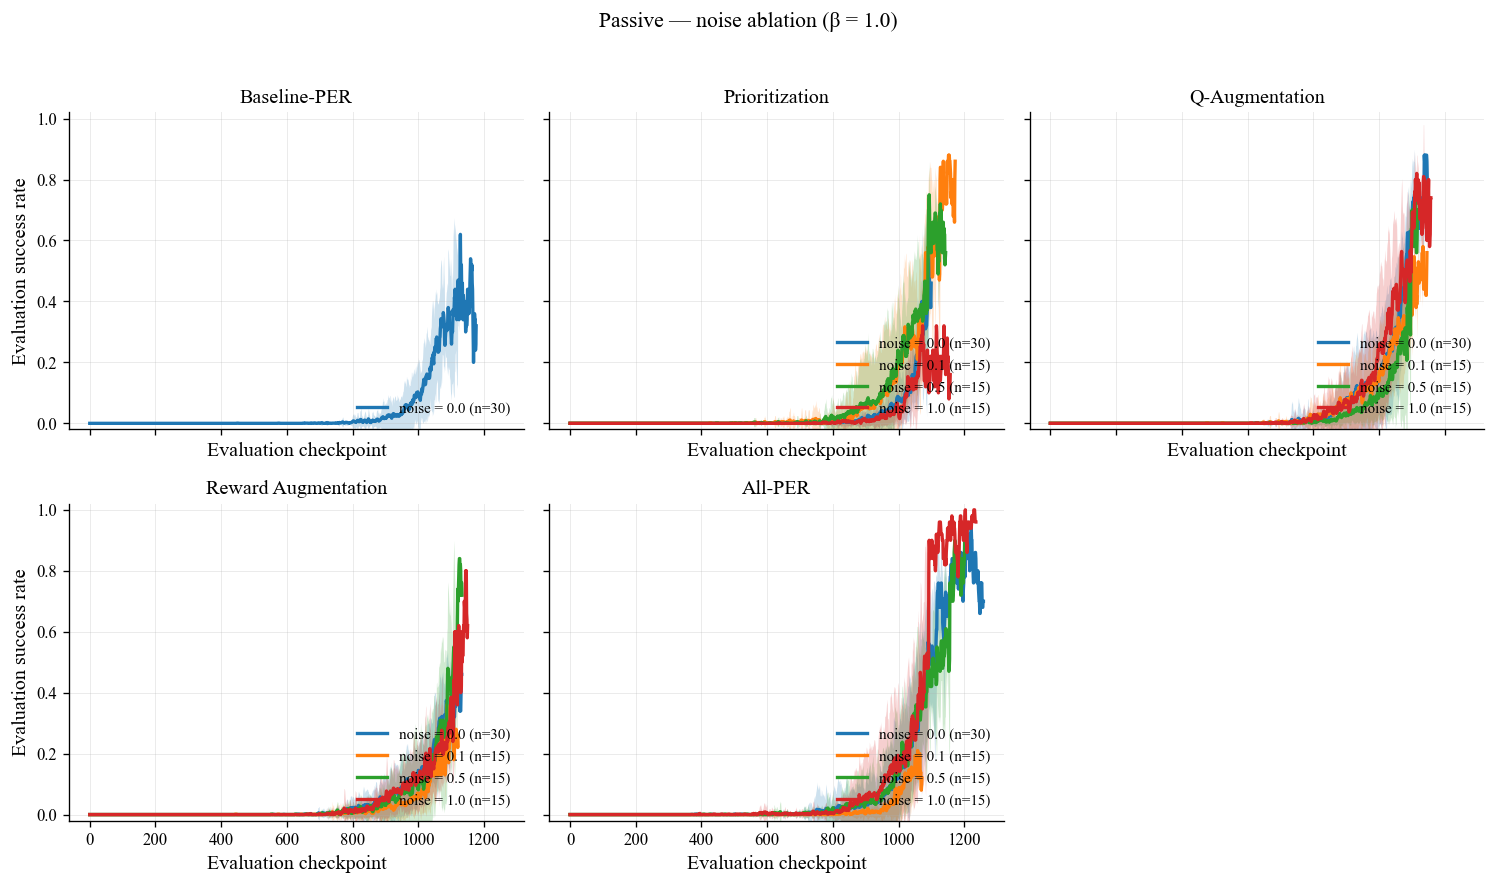

Saved figures_publication/ablation_model_noise__Active.pdf
Saved figures_publication/ablation_model_noise__Active.png


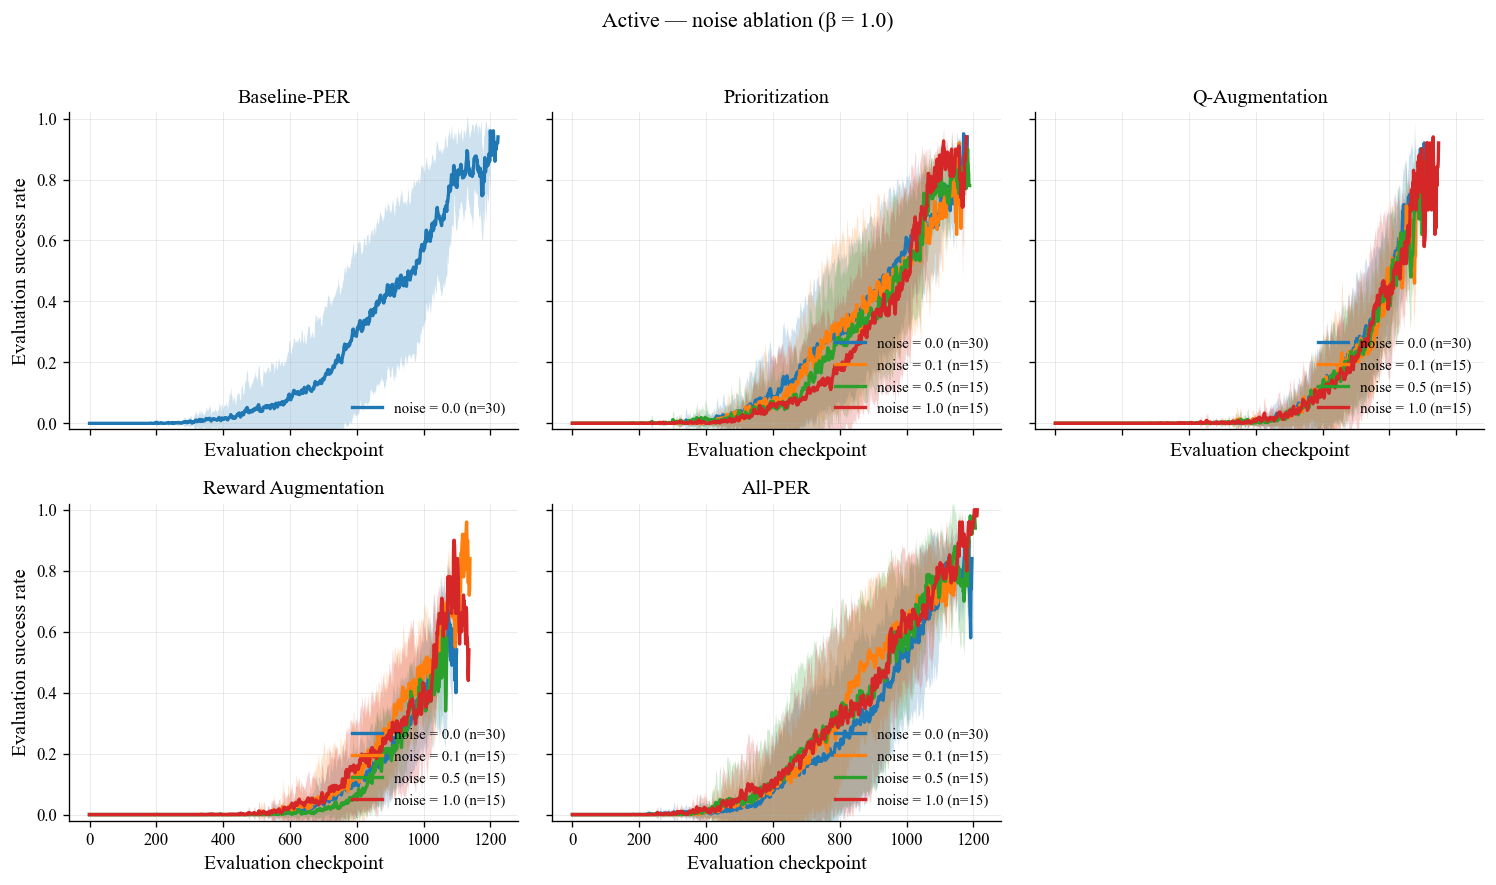

Saved figures_publication/ablation_model_noise__Pooled.pdf
Saved figures_publication/ablation_model_noise__Pooled.png


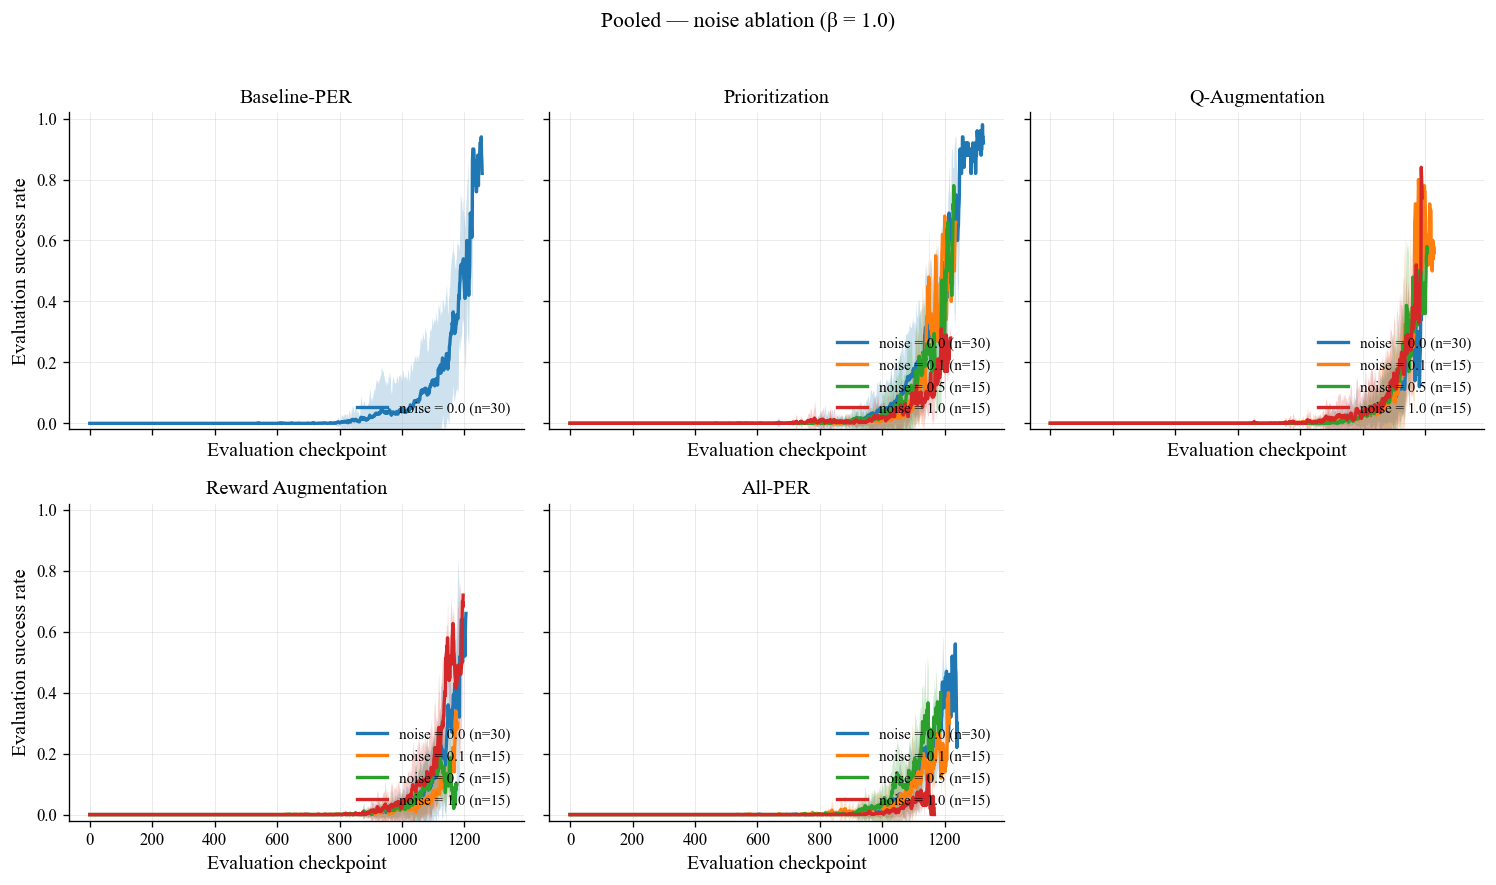

In [93]:
# --- Model-noise ablation: one figure per task (subplots = conditions) ---
plot_ablation_for_each_task(agg, ablation_kind="noise")


Saved figures_publication/ablation_neural_beta__Passive.pdf
Saved figures_publication/ablation_neural_beta__Passive.png


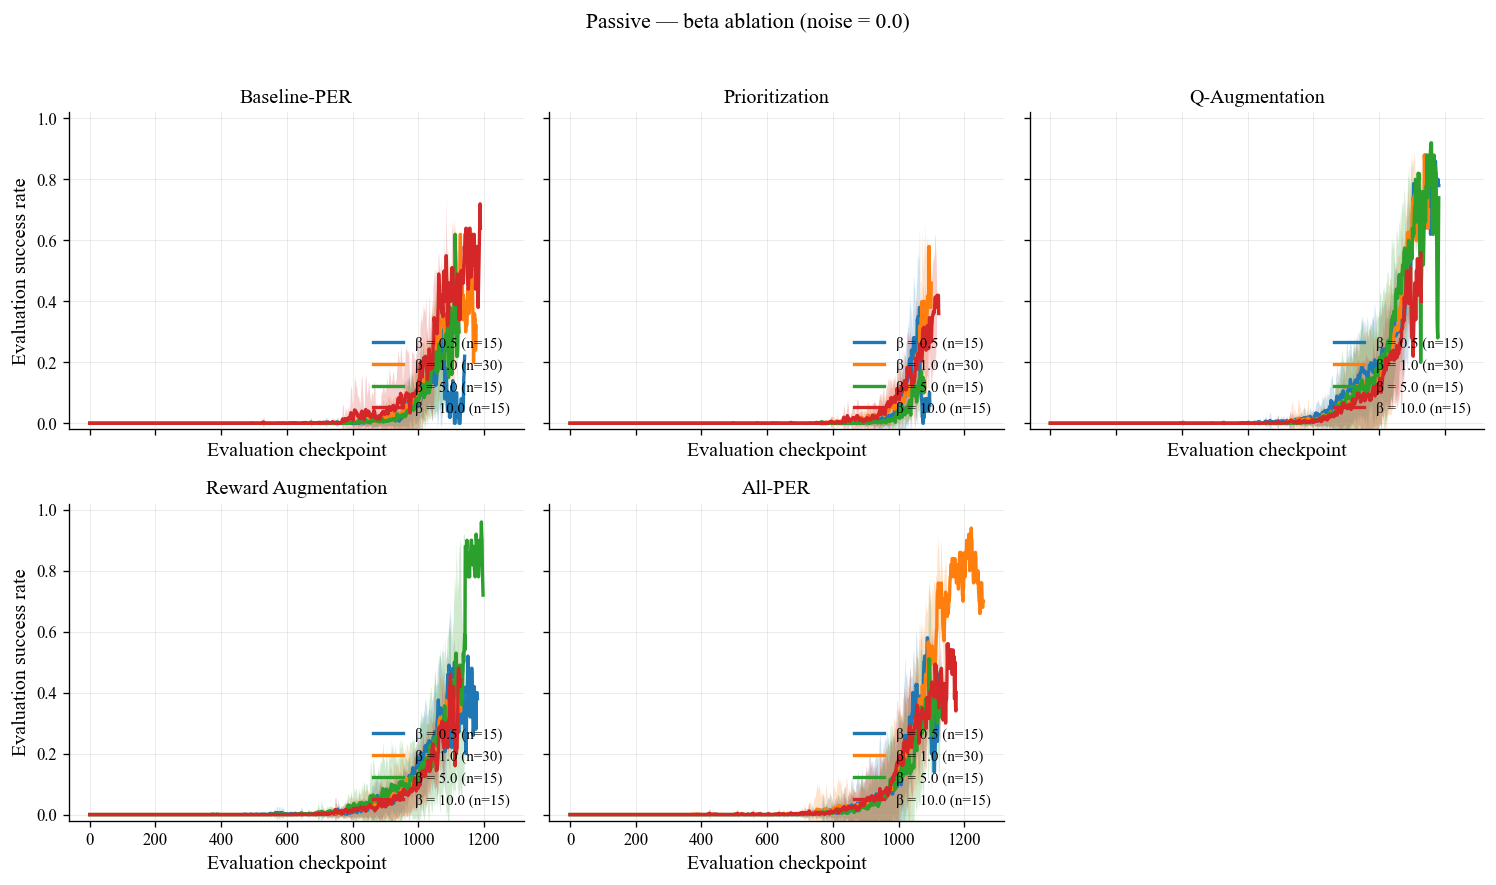

Saved figures_publication/ablation_neural_beta__Active.pdf
Saved figures_publication/ablation_neural_beta__Active.png


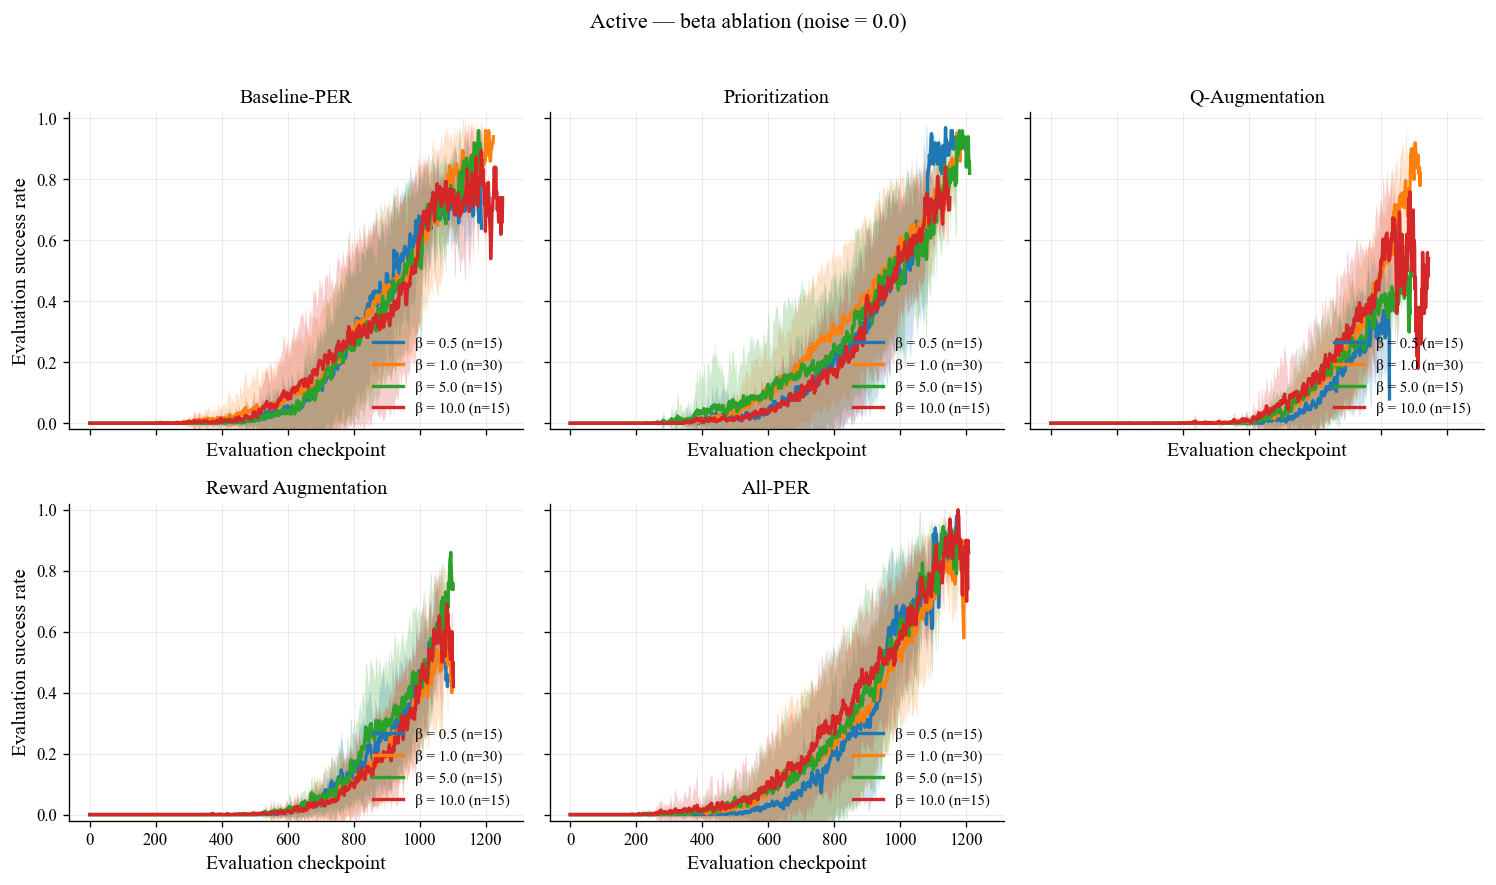

Saved figures_publication/ablation_neural_beta__Pooled.pdf
Saved figures_publication/ablation_neural_beta__Pooled.png


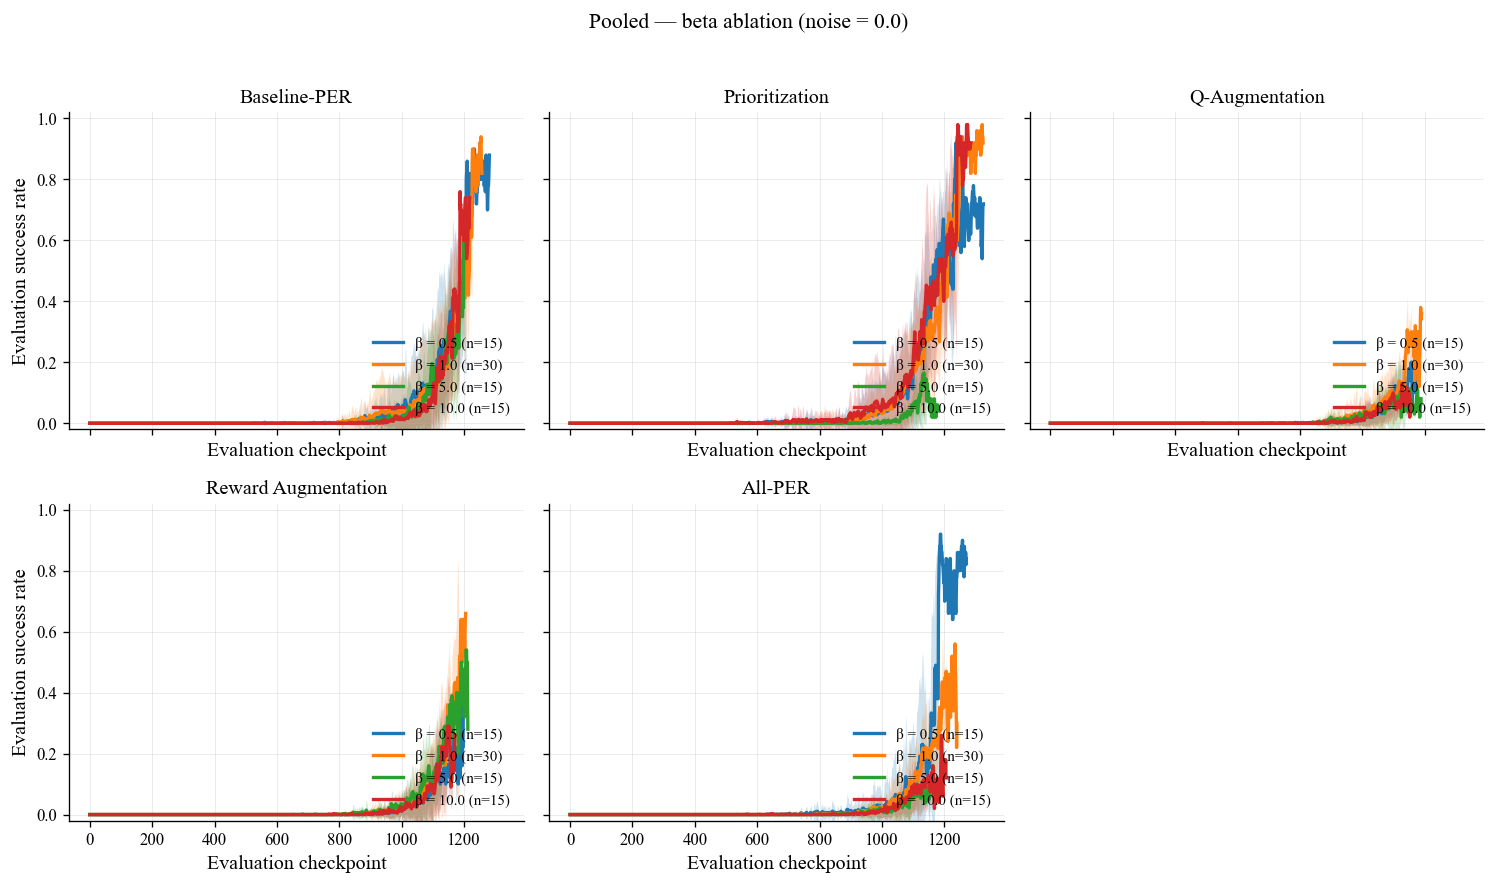

In [94]:
# --- Neural-β ablation: one figure per task (subplots = conditions) ---
plot_ablation_for_each_task(agg, ablation_kind="beta")


Saved figures_publication/conditions_best_ablations.pdf
Saved figures_publication/conditions_best_ablations.png


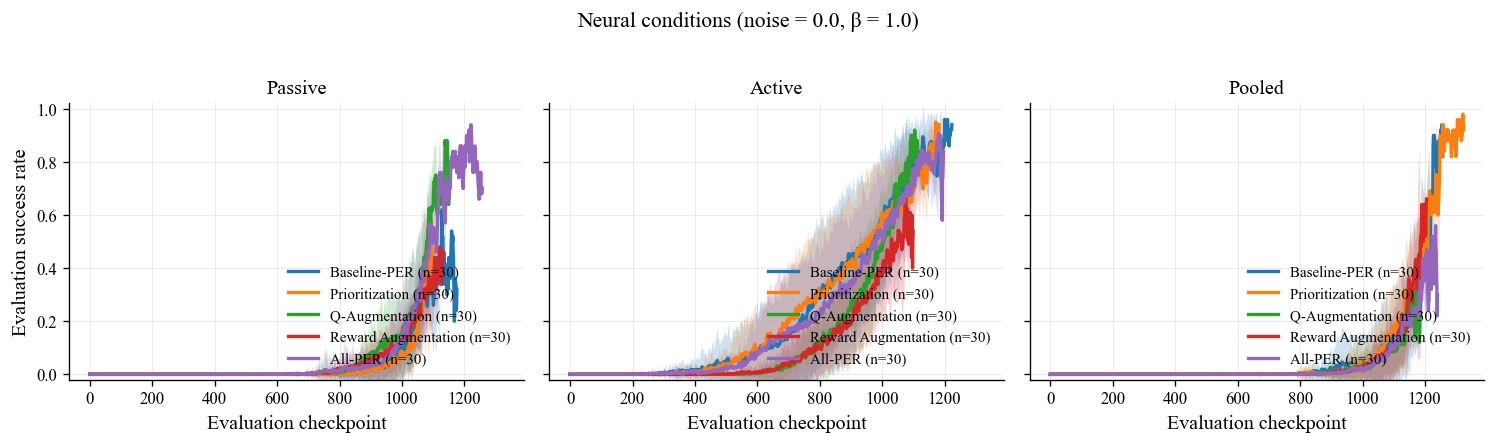

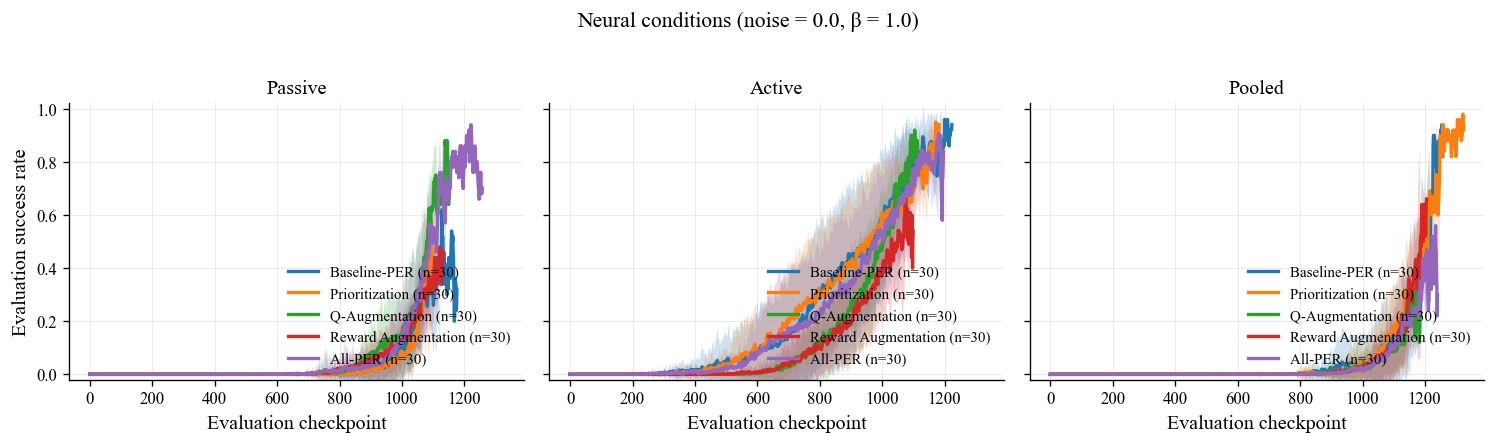

In [95]:
# --- Neural conditions at best ablations: one figure per task (subplot = condition) ---
plot_conditions_per_task(agg, noise=best_noise, beta=best_beta)
